# Complex Numbers — Lecture 3
## Homework Question · Modulus Properties 9–12 · Complex Numbers as Vectors · Triangle Inequality

**Source:** [Complex Numbers 03 | Detailed Discussion on Modulus | Class 11 | JEE](https://www.youtube.com/watch?v=TiFC2k88Ejo&list=PLF_7kfnwLFCFWA-D3XAPqcyB1z68dbgUg&index=3), Physics Wallah (Class 11), about 37 min

**Prerequisite:** Lecture 2 (conjugate, modulus, $z\bar z = |z|^2$, $|z_1z_2| = |z_1||z_2|$).

### What this lecture covers
1. **Homework from Lecture 2:** $|z_1| = 1$, $|z_2| = 2$, $|z_3| = 3$ and $|9z_1z_2 + 4z_1z_3 + z_2z_3| = 12$. Find $|z_1 + z_2 + z_3|$
2. Quick revision of modulus properties 1–8, with the proof of $|z_1z_2| = |z_1||z_2|$
3. **Property 9:** $|z_1 + z_2|^2$ in three forms
4. **Property 10:** $|z_1 - z_2|^2$ in three forms
5. **Property 11:** $|z_1 + z_2|^2 + |z_1 - z_2|^2 = 2\left(|z_1|^2 + |z_2|^2\right)$
6. Every complex number can be treated as a **position vector**
7. **Property 12: the triangle inequality** $\big||z_1| - |z_2|\big| \le |z_1 + z_2| \le |z_1| + |z_2|$, extended to $n$ numbers
8. **Question:** $|z_1 - 1| \le 1$, $|z_2 - 2| \le 2$, $|z_3 - 3| \le 3$. Find the greatest value of $|z_1 + z_2 + z_3|$

> The lecturer's advice: complex numbers are like a good friend. They don't click instantly, and you have to spend time with them. Once they do click, the questions become fun.

Sections marked *(extra)* go beyond what was said in the lecture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Same look as Lectures 1 and 2
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "animation.embed_limit": 30,
})
rng = np.random.default_rng(3)

def argand(ax, lim=2.5, ticks=1):
    # Draw the complex plane: real axis horizontal, imaginary axis vertical
    ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    t = np.arange(ticks, lim, ticks); t = np.r_[-t[::-1], 0, t]
    ax.set_xticks(t)
    ax.set_yticks(t, ["0" if v == 0 else "i" if v == 1 else "−i" if v == -1 else f"{v:g}i".replace("-", "−") for v in t])
    ax.set_xlabel("Re"); ax.set_ylabel("Im")

def arrow(ax, z0, z1, color, lw=2):
    z0, z1 = complex(z0), complex(z1)
    ax.annotate("", (z1.real, z1.imag), (z0.real, z0.imag),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=14, shrinkA=0, shrinkB=0))

def check(name, lhs, rhs):
    print(f"{name}:  holds on {np.isclose(lhs, rhs).mean()*100:.2f}% of {np.size(lhs):,} random samples")

def rand_z(n=100_000, s=5):
    return rng.uniform(-s, s, n) + 1j*rng.uniform(-s, s, n)

def on_circle(r, n=100_000):
    return r*np.exp(1j*rng.uniform(0, 2*np.pi, n))
print("ready")

ready


---
## 1. Homework from Lecture 2

**Q.** If $|z_1| = 1$, $|z_2| = 2$, $|z_3| = 3$ and $|9z_1z_2 + 4z_1z_3 + z_2z_3| = 12$, find $|z_1 + z_2 + z_3|$.

**Key idea:** turn the numbers $9, 4, 1$ into complex numbers using $z\bar z = |z|^2$:
$$9 = |z_3|^2 = z_3\bar z_3, \qquad 4 = |z_2|^2 = z_2\bar z_2, \qquad 1 = |z_1|^2 = z_1\bar z_1$$

Substitute these:
$$9z_1z_2 + 4z_1z_3 + z_2z_3 = z_3\bar z_3\,z_1z_2 + z_2\bar z_2\,z_1z_3 + z_1\bar z_1\,z_2z_3$$
Every term contains $z_1z_2z_3$. Take it out as a common factor:
$$= z_1z_2z_3\left(\bar z_3 + \bar z_2 + \bar z_1\right) = z_1z_2z_3\;\overline{(z_1 + z_2 + z_3)}$$
The last step uses "the bar can go on each term or on the whole sum" (Lecture 2, property 5).

Take the modulus. The mod passes through products (property 6), and $|\bar w| = |w|$:
$$12 = |z_1|\,|z_2|\,|z_3|\;\left|\overline{z_1 + z_2 + z_3}\right| = 1\cdot2\cdot3\cdot|z_1 + z_2 + z_3|$$
$$\boxed{|z_1 + z_2 + z_3| = 2}$$

In [2]:
z1, z2, z3 = on_circle(1), on_circle(2), on_circle(3)
lhs = np.abs(9*z1*z2 + 4*z1*z3 + z2*z3)
check("|9z1z2 + 4z1z3 + z2z3| = 6 |z1 + z2 + z3|  (any z's with moduli 1, 2, 3)", lhs, 6*np.abs(z1 + z2 + z3))

|9z1z2 + 4z1z3 + z2z3| = 6 |z1 + z2 + z3|  (any z's with moduli 1, 2, 3):  holds on 100.00% of 100,000 random samples


### Picture *(extra)*: the identity behind the answer
For **any** $z_1, z_2, z_3$ on circles of radius $1, 2, 3$, the step above shows
$$|9z_1z_2 + 4z_1z_3 + z_2z_3| = 6\,|z_1 + z_2 + z_3|$$
So if you scatter random choices, every point lands on the line of slope $6$. The question just picks the point where the vertical value is $12$.

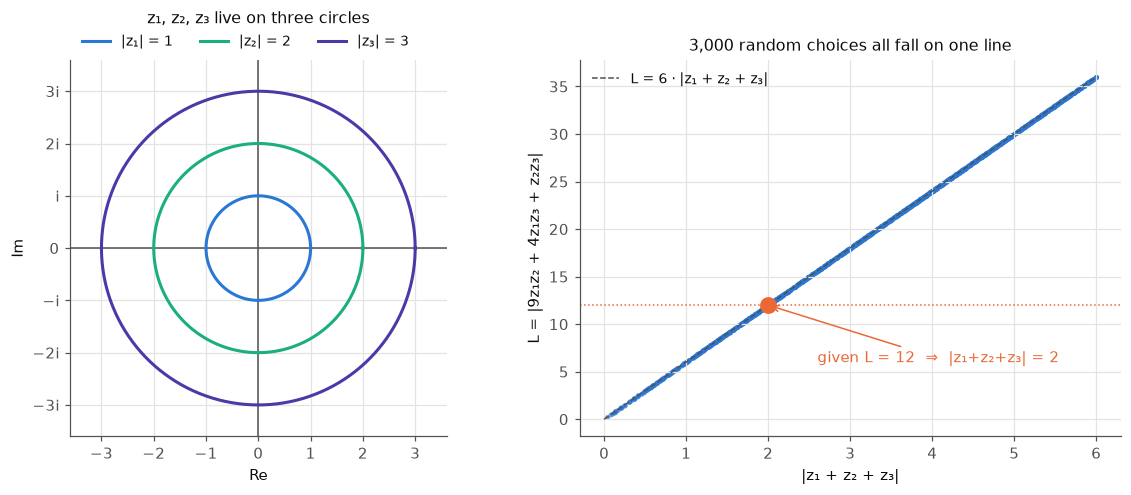

In [3]:
n = 3000
w1, w2, w3 = on_circle(1, n), on_circle(2, n), on_circle(3, n)
S, L = np.abs(w1 + w2 + w3), np.abs(9*w1*w2 + 4*w1*w3 + w2*w3)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
ax = axes[0]; argand(ax, lim=3.6)
th = np.linspace(0, 2*np.pi, 300)
for r, c, lab in [(1, BLUE, "|z₁| = 1"), (2, AQUA, "|z₂| = 2"), (3, VIOLET, "|z₃| = 3")]:
    ax.plot(r*np.cos(th), r*np.sin(th), color=c, lw=2, label=lab)
ax.legend(frameon=False, fontsize=9, loc="upper left", ncol=3, bbox_to_anchor=(0, 1.1))
ax.set_title("z₁, z₂, z₃ live on three circles", fontsize=10.5, pad=24)
ax = axes[1]
ax.scatter(S, L, s=5, color=BLUE, alpha=0.35)
ax.plot([0, 6], [0, 36], color=INK2, lw=1, ls="--", label="L = 6 · |z₁ + z₂ + z₃|")
ax.plot([2], [12], "o", color=ORANGE, ms=10, zorder=5); ax.axhline(12, color=ORANGE, lw=1, ls=":")
ax.annotate("given L = 12  ⇒  |z₁+z₂+z₃| = 2", (2, 12), xytext=(2.6, 6), color=ORANGE,
            arrowprops=dict(arrowstyle="->", color=ORANGE))
ax.set_xlabel("|z₁ + z₂ + z₃|"); ax.set_ylabel("L = |9z₁z₂ + 4z₁z₃ + z₂z₃|")
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_title("3,000 random choices all fall on one line", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## 2. Revision: Modulus Properties 1–8

| # | Property |
|---|---|
| 1 | $\lvert z\rvert = \sqrt{a^2 + b^2}$ = distance of $z$ from the origin |
| 2 | $\lvert z\rvert = \lvert\bar z\rvert$ |
| 3 | $z\bar z = \lvert z\rvert^2$ |
| 4 | $\lvert z_1 \pm z_2\rvert \ne \lvert z_1\rvert \pm \lvert z_2\rvert$ in general. **Students often make this mistake** |
| 5 | $\lvert z_1z_2\cdots z_n\rvert = \lvert z_1\rvert\lvert z_2\rvert\cdots\lvert z_n\rvert$ |
| 6 | $\lvert z_1/z_2\rvert = \lvert z_1\rvert/\lvert z_2\rvert$, with $z_2 \ne 0$ |
| 7 | $\lvert z^n\rvert = \lvert z\rvert^n$ |

*(The lecturer's numbering here differs slightly from Lecture 2. The content is the same.)*

**Proof of $|z_1z_2| = |z_1||z_2|$** (homework from Lecture 2). Let $z_1 = a_1 + ib_1$ and $z_2 = a_2 + ib_2$. Then $z_1z_2 = (a_1a_2 - b_1b_2) + i(a_1b_2 + a_2b_1)$, so
$$|z_1z_2|^2 = (a_1a_2 - b_1b_2)^2 + (a_1b_2 + a_2b_1)^2 = a_1^2a_2^2 + b_1^2b_2^2 + a_1^2b_2^2 + a_2^2b_1^2 \qquad (1)$$
The cross terms $\mp 2a_1a_2b_1b_2$ cancel. On the other side:
$$|z_1|^2|z_2|^2 = (a_1^2 + b_1^2)(a_2^2 + b_2^2) = a_1^2a_2^2 + a_1^2b_2^2 + b_1^2a_2^2 + b_1^2b_2^2 \qquad (2)$$
$(1)$ and $(2)$ are identical, so $|z_1z_2| = |z_1||z_2|$. $\blacksquare$

> Before going further, the lecturer asks you to make sure every property of conjugate and modulus so far is solid. The rest builds on them.

---
## 3. Property 9: $|z_1 + z_2|^2$

$$\boxed{|z_1 + z_2|^2 = |z_1|^2 + |z_2|^2 + z_1\bar z_2 + \bar z_1 z_2}$$

**Proof.** Use $|w|^2 = w\bar w$ with $w = z_1 + z_2$, and pass the bar through the sum:
$$|z_1 + z_2|^2 = (z_1 + z_2)\,\overline{(z_1 + z_2)} = (z_1 + z_2)(\bar z_1 + \bar z_2)$$
Open the brackets:
$$= z_1\bar z_1 + z_1\bar z_2 + z_2\bar z_1 + z_2\bar z_2 = |z_1|^2 + |z_2|^2 + z_1\bar z_2 + \bar z_1z_2 \quad\blacksquare$$

### Second form
Look at the two middle terms. $\bar z_1 z_2$ is the **conjugate** of $z_1\bar z_2$, because $\overline{z_1\bar z_2} = \bar z_1\,\overline{\bar z_2} = \bar z_1 z_2$. A number plus its conjugate is twice its real part (Lecture 2, property 8):
$$\boxed{|z_1 + z_2|^2 = |z_1|^2 + |z_2|^2 + 2\operatorname{Re}\left(z_1\bar z_2\right)}$$

### Third form
$$\boxed{|z_1 + z_2|^2 = |z_1|^2 + |z_2|^2 + 2|z_1||z_2|\cos(\theta_1 - \theta_2)}$$
where $\theta_1, \theta_2$ are the angles that $z_1, z_2$ make with the positive real axis. The lecturer explains where this comes from in the next lecture on the **polar form**. For now, memorise it. *(A quick preview is below.)*

> All three forms should be memorised.

## 4. Property 10: $|z_1 - z_2|^2$

Replace $z_2$ by $-z_2$ everywhere in property 9:
$$\boxed{|z_1 - z_2|^2 = |z_1|^2 + |z_2|^2 - \left(z_1\bar z_2 + \bar z_1z_2\right) = |z_1|^2 + |z_2|^2 - 2\operatorname{Re}(z_1\bar z_2) = |z_1|^2 + |z_2|^2 - 2|z_1||z_2|\cos(\theta_1 - \theta_2)}$$

## 5. Property 11: add properties 9 and 10
The middle terms cancel and the squares double:
$$\boxed{|z_1 + z_2|^2 + |z_1 - z_2|^2 = 2\left(|z_1|^2 + |z_2|^2\right)}$$

In [4]:
z1, z2 = rand_z(), rand_z()
m1, m2 = np.abs(z1), np.abs(z2)
th = np.angle(z1) - np.angle(z2)
check("P9  form 1: |z1+z2|² = |z1|² + |z2|² + z1z̄2 + z̄1z2", np.abs(z1 + z2)**2, m1**2 + m2**2 + z1*np.conj(z2) + np.conj(z1)*z2)
check("P9  form 2: … + 2 Re(z1 z̄2)                     ", np.abs(z1 + z2)**2, m1**2 + m2**2 + 2*(z1*np.conj(z2)).real)
check("P9  form 3: … + 2|z1||z2| cos(θ1 − θ2)          ", np.abs(z1 + z2)**2, m1**2 + m2**2 + 2*m1*m2*np.cos(th))
check("P10 form 3: |z1−z2|² = … − 2|z1||z2| cos(θ1 − θ2)", np.abs(z1 - z2)**2, m1**2 + m2**2 - 2*m1*m2*np.cos(th))
check("P11 |z1+z2|² + |z1−z2|² = 2(|z1|² + |z2|²)       ", np.abs(z1 + z2)**2 + np.abs(z1 - z2)**2, 2*(m1**2 + m2**2))

P9  form 1: |z1+z2|² = |z1|² + |z2|² + z1z̄2 + z̄1z2:  holds on 100.00% of 100,000 random samples
P9  form 2: … + 2 Re(z1 z̄2)                     :  holds on 100.00% of 100,000 random samples
P9  form 3: … + 2|z1||z2| cos(θ1 − θ2)          :  holds on 100.00% of 100,000 random samples
P10 form 3: |z1−z2|² = … − 2|z1||z2| cos(θ1 − θ2):  holds on 100.00% of 100,000 random samples
P11 |z1+z2|² + |z1−z2|² = 2(|z1|² + |z2|²)       :  holds on 100.00% of 100,000 random samples


### Preview *(extra)*: why $\operatorname{Re}(z_1\bar z_2) = |z_1||z_2|\cos(\theta_1 - \theta_2)$
Write it out with $z_1 = a_1 + ib_1$, $z_2 = a_2 + ib_2$:
$$z_1\bar z_2 = (a_1 + ib_1)(a_2 - ib_2) = (a_1a_2 + b_1b_2) + i(b_1a_2 - a_1b_2)$$
The real part $a_1a_2 + b_1b_2$ is exactly the **dot product** of the vectors $(a_1, b_1)$ and $(a_2, b_2)$. A dot product equals $|\vec u||\vec v|\cos(\text{angle between})$, and the angle between them is $\theta_1 - \theta_2$.

So property 9 is just the **cosine rule** from geometry, written in complex numbers. And property 11 is the **parallelogram law**: the squares of the two diagonals ($|z_1 + z_2|$ and $|z_1 - z_2|$) add up to the squares of all four sides.

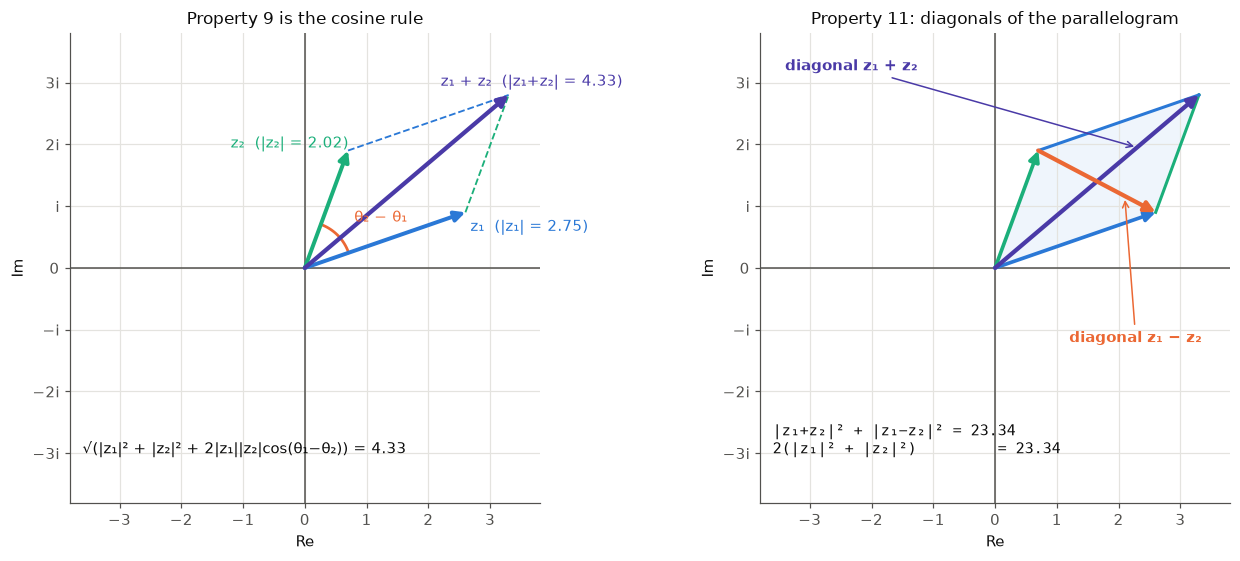

In [5]:
z1, z2 = 2.6 + 0.9j, 0.7 + 1.9j
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

ax = axes[0]; argand(ax, lim=3.8)
arrow(ax, 0, z1, BLUE, 2.6); arrow(ax, 0, z2, AQUA, 2.6); arrow(ax, 0, z1 + z2, VIOLET, 2.8)
ax.plot([z1.real, (z1+z2).real], [z1.imag, (z1+z2).imag], color=AQUA, lw=1.2, ls="--")
ax.plot([z2.real, (z1+z2).real], [z2.imag, (z1+z2).imag], color=BLUE, lw=1.2, ls="--")
a1, a2 = np.angle(z1), np.angle(z2); t = np.linspace(a1, a2, 50)
ax.plot(0.75*np.cos(t), 0.75*np.sin(t), color=ORANGE, lw=1.8)
ax.text(0.8, 0.75, "θ₂ − θ₁", color=ORANGE, fontsize=10)
ax.text(z1.real + 0.08, z1.imag - 0.3, f"z₁  (|z₁| = {abs(z1):.2f})", color=BLUE, fontsize=9.5)
ax.text(z2.real - 1.9, z2.imag + 0.05, f"z₂  (|z₂| = {abs(z2):.2f})", color=AQUA, fontsize=9.5)
ax.text((z1+z2).real - 1.1, (z1+z2).imag + 0.15, f"z₁ + z₂  (|z₁+z₂| = {abs(z1+z2):.2f})", color=VIOLET, fontsize=9.5)
c = np.cos(a1 - a2); rhs = np.sqrt(abs(z1)**2 + abs(z2)**2 + 2*abs(z1)*abs(z2)*c)
ax.text(-3.6, -3.0, f"√(|z₁|² + |z₂|² + 2|z₁||z₂|cos(θ₁−θ₂)) = {rhs:.2f}", fontsize=9.5, color=INK)
ax.set_title("Property 9 is the cosine rule", fontsize=11)

ax = axes[1]; argand(ax, lim=3.8)
P = [0, z1, z1 + z2, z2, 0]
ax.fill([p.real for p in map(complex, P)], [p.imag for p in map(complex, P)], color=BLUE, alpha=0.07)
arrow(ax, 0, z1, BLUE, 2.4); arrow(ax, 0, z2, AQUA, 2.4)
ax.plot([z1.real, (z1+z2).real], [z1.imag, (z1+z2).imag], color=AQUA, lw=2)
ax.plot([z2.real, (z1+z2).real], [z2.imag, (z1+z2).imag], color=BLUE, lw=2)
arrow(ax, 0, z1 + z2, VIOLET, 2.8); arrow(ax, z2, z1, ORANGE, 2.8)
ax.annotate("diagonal z₁ + z₂", (2.3, 1.95), xytext=(-3.4, 3.2), color=VIOLET, weight="bold",
            arrowprops=dict(arrowstyle="->", color=VIOLET, lw=1))
ax.annotate("diagonal z₁ − z₂", (2.1, 1.15), xytext=(1.2, -1.2), color=ORANGE, weight="bold",
            arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1))
lhs = abs(z1 + z2)**2 + abs(z1 - z2)**2; r = 2*(abs(z1)**2 + abs(z2)**2)
ax.text(-3.6, -3.0, f"|z₁+z₂|² + |z₁−z₂|² = {lhs:.2f}\n2(|z₁|² + |z₂|²)         = {r:.2f}", fontsize=9.5, family="monospace")
ax.set_title("Property 11: diagonals of the parallelogram", fontsize=11)
plt.tight_layout(); plt.show()

---
## 6. Complex Numbers as Vectors

From Lecture 2, the point $(a, b)$, the complex number $a + ib$ and the position vector $a\hat\imath + b\hat\jmath$ all carry the same information. So:

> **Every complex number can be treated as a position vector.** $\quad a + ib \;\longleftrightarrow\; a\hat\imath + b\hat\jmath$

This is the **vectorial representation** of complex numbers. Under it:
- $|z|$ is the **length** of the vector.
- $z_1 + z_2$ is **vector addition**: the triangle law, or tip to tail.

---
## 7. Property 12: The Triangle Inequality

### First, ordinary triangles
In a triangle with sides $a, b, c$, **the sum of two sides is always greater than the third**, because a straight line is the shortest path:
$$a + b > c, \qquad b + c > a, \qquad c + a > b$$
They become **equal** only if the triangle collapses flat, with zero area and the third vertex lying on the opposite side. So in general $a + b \ge c$.

Moving terms across gives the other version: $c \ge |a - b|$. The modulus is there so the difference can't be negative.

### Now with complex numbers
Draw $z_1$ from the origin, then $z_2$ tip to tail. By the triangle law, the closing side is $z_1 + z_2$. The three sides have lengths $|z_1|$, $|z_2|$, $|z_1 + z_2|$, so
$$\boxed{\big|\,|z_1| - |z_2|\,\big| \;\le\; |z_1 + z_2| \;\le\; |z_1| + |z_2|}$$
This is the **triangle inequality in terms of complex numbers**. Equality holds only when the triangle is flat:
- on the right when $z_1, z_2$ point the **same** way,
- on the left when they point **opposite** ways.

### Extending to $n$ numbers
Apply it repeatedly. A path made of many pieces is never shorter than the straight line:
$$|z_1 + z_2 + z_3| \le |z_1| + |z_2| + |z_3|, \qquad |z_1 + z_2 + \cdots + z_n| \le |z_1| + |z_2| + \cdots + |z_n|$$
So the **maximum** possible value of $|z_1 + \cdots + z_n|$ is $|z_1| + \cdots + |z_n|$.

In [6]:
z1, z2 = rand_z(), rand_z()
s = np.abs(z1 + z2)
print("upper  |z1+z2| ≤ |z1| + |z2|     :", np.all(s <= np.abs(z1) + np.abs(z2) + 1e-12))
print("lower  |z1+z2| ≥ ||z1| − |z2||   :", np.all(s >= np.abs(np.abs(z1) - np.abs(z2)) - 1e-12))
Z = rand_z(10*100_000).reshape(10, -1)
print("n = 10 |Σz| ≤ Σ|z|               :", np.all(np.abs(Z.sum(0)) <= np.abs(Z).sum(0) + 1e-9))
print("equality, same direction  : |(1+i) + (3+3i)| =", abs(4+4j), " |1+i| + |3+3i| =", abs(1+1j) + abs(3+3j))
print("equality, opposite        : |(1+i) − (3+3i)| =", abs(-2-2j), " ||1+i| − |3+3i|| =", abs(abs(1+1j) - abs(3+3j)))

upper  |z1+z2| ≤ |z1| + |z2|     : True
lower  |z1+z2| ≥ ||z1| − |z2||   : True
n = 10 |Σz| ≤ Σ|z|               : True
equality, same direction  : |(1+i) + (3+3i)| = 5.656854249492381  |1+i| + |3+3i| = 5.65685424949238
equality, opposite        : |(1+i) − (3+3i)| = 2.8284271247461903  ||1+i| − |3+3i|| = 2.82842712474619


### Picture *(extra)*: both bounds at once
Fix $z_1$ and let $z_2$ take every direction with a fixed length. Then $z_1 + z_2$ runs around a **circle** of radius $|z_2|$ centred at $z_1$. Its distance from the origin is smallest at the near side, $\big||z_1| - |z_2|\big|$, and largest at the far side, $|z_1| + |z_2|$. So every value of $|z_1 + z_2|$ lies in the shaded **ring** between those two radii.

On the right, a path of many vectors placed tip to tail is never shorter than the straight line from start to finish.

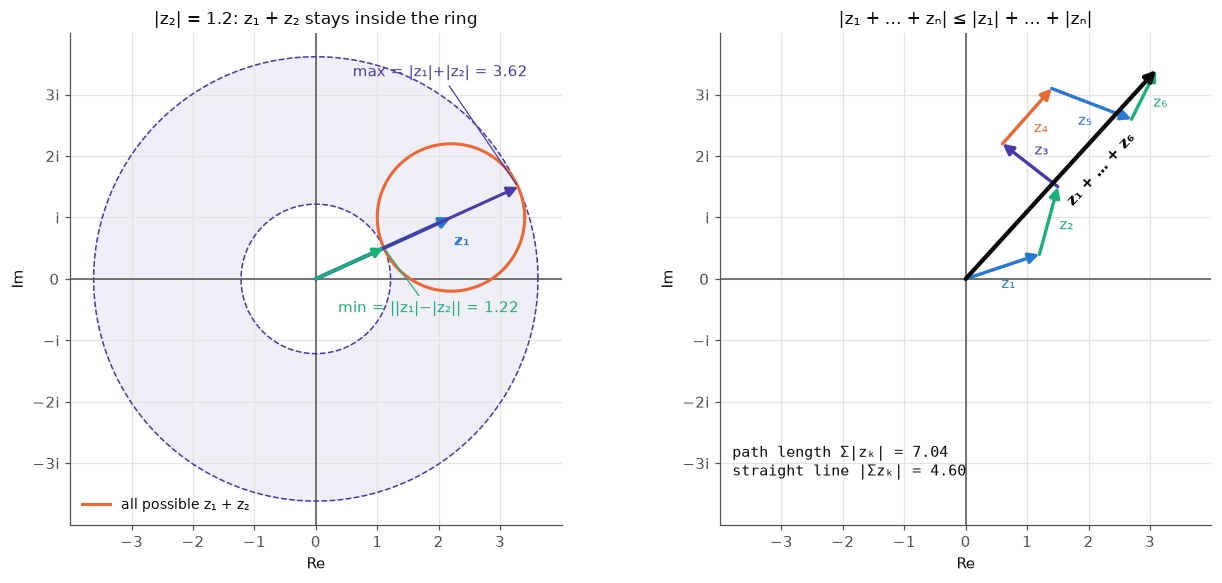

In [7]:
z1, r2 = 2.2 + 1.0j, 1.2
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
ax = axes[0]; argand(ax, lim=4)
th = np.linspace(0, 2*np.pi, 400)
rmin, rmax = abs(abs(z1) - r2), abs(z1) + r2
ax.fill(np.r_[rmax*np.cos(th), rmin*np.cos(th[::-1])], np.r_[rmax*np.sin(th), rmin*np.sin(th[::-1])], color=VIOLET, alpha=0.08)
ax.plot(rmax*np.cos(th), rmax*np.sin(th), color=VIOLET, lw=1, ls="--"); ax.plot(rmin*np.cos(th), rmin*np.sin(th), color=VIOLET, lw=1, ls="--")
ax.plot(z1.real + r2*np.cos(th), z1.imag + r2*np.sin(th), color=ORANGE, lw=2, label="all possible z₁ + z₂")
u = z1/abs(z1)
arrow(ax, 0, z1, BLUE, 2.6)
arrow(ax, 0, z1 + r2*u, VIOLET, 2); arrow(ax, 0, z1 - r2*u, AQUA, 2)
ax.annotate(f"max = |z₁|+|z₂| = {rmax:.2f}", ((z1 + r2*u).real, (z1 + r2*u).imag), xytext=(0.6, 3.3), color=VIOLET, fontsize=9.5,
            arrowprops=dict(arrowstyle="-", color=VIOLET, lw=0.8))
ax.annotate(f"min = ||z₁|−|z₂|| = {rmin:.2f}", ((z1 - r2*u).real, (z1 - r2*u).imag), xytext=(-30, -42), textcoords="offset points", color=AQUA, fontsize=9.5,
            arrowprops=dict(arrowstyle="-", color=AQUA, lw=0.8))
ax.text(z1.real + 0.05, z1.imag - 0.45, "z₁", color=BLUE, weight="bold")
ax.legend(frameon=False, fontsize=9, loc="lower left")
ax.set_title(f"|z₂| = {r2}: z₁ + z₂ stays inside the ring", fontsize=11)

ax = axes[1]; argand(ax, lim=4)
steps = np.array([1.2 + 0.4j, 0.3 + 1.1j, -0.9 + 0.7j, 0.8 + 0.9j, 1.3 - 0.5j, 0.4 + 0.8j])
pos = np.r_[0, np.cumsum(steps)]
cols = [BLUE, AQUA, VIOLET, ORANGE, BLUE, AQUA]
for k in range(len(steps)):
    arrow(ax, pos[k], pos[k+1], cols[k], 2.2)
    m = (pos[k] + pos[k+1])/2 - 0.3j*steps[k]/abs(steps[k])  # label just to the right of each arrow
    ax.text(m.real, m.imag, f"z{'₁₂₃₄₅₆'[k]}", color=cols[k], fontsize=9.5, ha="center", va="center")
arrow(ax, 0, pos[-1], INK, 2.8)
ax.text(1.6, 1.2, "z₁ + … + z₆", color=INK, weight="bold", rotation=np.degrees(np.angle(pos[-1])))
ax.text(-3.8, -3.2, f"path length Σ|zₖ| = {np.abs(steps).sum():.2f}\nstraight line |Σzₖ| = {abs(pos[-1]):.2f}", fontsize=10, family="monospace")
ax.set_title("|z₁ + … + zₙ| ≤ |z₁| + … + |zₙ|", fontsize=11)
plt.tight_layout(); plt.show()

---
## 8. Question: Greatest Value of $|z_1 + z_2 + z_3|$

**Q.** If $|z_1 - 1| \le 1$, $|z_2 - 2| \le 2$ and $|z_3 - 3| \le 3$, find the greatest value of $|z_1 + z_2 + z_3|$.

**Idea:** we only know things about $z_1 - 1$, $z_2 - 2$ and $z_3 - 3$, so **rewrite the target using exactly those pieces**. Subtract and add back:
$$z_1 + z_2 + z_3 = (z_1 - 1) + (z_2 - 2) + (z_3 - 3) + 6$$
"I broke it this way because I know about these pieces."

Treat each bracket, and the $6$, as a separate complex number and apply the **triangle inequality for 4 numbers**:
$$|z_1 + z_2 + z_3| \le |z_1 - 1| + |z_2 - 2| + |z_3 - 3| + |6| \le 1 + 2 + 3 + 6$$
$$\boxed{|z_1 + z_2 + z_3|_{\max} = 12}$$
The maximum happens when every piece is at its largest **and** they all point the same way, along the positive real axis like the $6$: $z_1 = 2$, $z_2 = 4$, $z_3 = 6$, giving $|2 + 4 + 6| = 12$.

### Geometric meaning *(extra)*
$|z_1 - 1| \le 1$ means $z_1$ is within distance $1$ of the point $1$. That's a **disc** of radius $1$ centred at $1$. Likewise $z_2$ lies in a disc of radius 2 centred at 2, and $z_3$ in a disc of radius 3 centred at 3. All three discs pass through the origin and stretch right as far as $2$, $4$ and $6$. In the animation each $z_k$ wanders inside its disc. The sum never gets further than $12$ from the origin, and reaches $12$ only when all three sit at their right-most points.

In [8]:
z_end = np.array([2, 4, 6], dtype=complex)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), dpi=72, gridspec_kw=dict(width_ratios=[1, 1.25]))
ax = axes[0]; argand(ax, lim=6.5, ticks=2)
th = np.linspace(0, 2*np.pi, 300); cols = [BLUE, AQUA, VIOLET]
for k, c in enumerate(cols):
    r = k + 1
    ax.fill(r + r*np.cos(th), r*np.sin(th), color=c, alpha=0.08); ax.plot(r + r*np.cos(th), r*np.sin(th), color=c, lw=1.5)
pts = [ax.plot([], [], "o", color=c, ms=9, mec="white", zorder=5)[0] for c in cols]
lbl = [ax.text(0, 0, f"z{'₁₂₃'[k]}", color=c, weight="bold") for k, c in enumerate(cols)]
ax.set_title("|z₁−1| ≤ 1,  |z₂−2| ≤ 2,  |z₃−3| ≤ 3", fontsize=10.5)

ax2 = axes[1]; argand(ax2, lim=13, ticks=4)
ax2.plot(12*np.cos(th), 12*np.sin(th), color=ORANGE, lw=1.5, ls="--", label="radius 12 (the bound)")
trail, = ax2.plot([], [], ".", color=INK2, ms=3, alpha=0.5)
sv, = ax2.plot([], [], color=ORANGE, lw=2.5); sd, = ax2.plot([], [], "o", color=ORANGE, ms=9)
txt = ax2.text(-12.5, -12, "", fontsize=10, family="monospace")
ax2.legend(frameon=False, fontsize=9, loc="upper left"); ax2.set_title("z₁ + z₂ + z₃ never leaves the circle of radius 12", fontsize=10.5)

N = 54
# Wander randomly for a while, then glide each z_k to its right-most point 2, 4, 6
walk = []
for k in range(3):
    r = k + 1
    ang = rng.uniform(0, 2*np.pi, 6); rad = r*np.sqrt(rng.uniform(0, 1, 6))
    key = np.r_[r + rad*np.exp(1j*ang), z_end[k], z_end[k]]
    tk = np.linspace(0, 1, len(key)); tt = np.linspace(0, 1, N)
    walk.append(np.interp(tt, tk, key.real) + 1j*np.interp(tt, tk, key.imag))
walk = np.array(walk); hist = []
def update(f):
    z = walk[:, f]; s = z.sum(); hist.append(s)
    for k in range(3):
        pts[k].set_data([z[k].real], [z[k].imag]); lbl[k].set_position((z[k].real + 0.2, z[k].imag + 0.25))
    H = np.array(hist[-N:]); trail.set_data(H.real, H.imag)
    sv.set_data([0, s.real], [0, s.imag]); sd.set_data([s.real], [s.imag])
    txt.set_text(f"|z₁+z₂+z₃| = {abs(s):5.2f}  ≤ 12" + ("   ← maximum!" if abs(s) > 11.99 else ""))
    return (*pts, *lbl, trail, sv, sd, txt)
anim = animation.FuncAnimation(fig, update, frames=N, interval=120, blit=True)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

In [9]:
# Brute-force check: sample many points inside the three discs and look for the largest |z1 + z2 + z3|
def in_disc(c, r, n=400_000):
    return c + r*np.sqrt(rng.uniform(0, 1, n))*np.exp(1j*rng.uniform(0, 2*np.pi, n))
S = np.abs(in_disc(1, 1) + in_disc(2, 2) + in_disc(3, 3))
print(f"largest |z1+z2+z3| among 400,000 random samples: {S.max():.4f}   (never exceeds 12)")
print("at z1 = 2, z2 = 4, z3 = 6:", abs(2 + 4 + 6), "   constraints:", abs(2 - 1) <= 1, abs(4 - 2) <= 2, abs(6 - 3) <= 3)

largest |z1+z2+z3| among 400,000 random samples: 11.8003   (never exceeds 12)
at z1 = 2, z2 = 4, z3 = 6: 12    constraints: True True True


---
## Summary

| # | Property | Remember it as |
|---|---|---|
| 9 | $\lvert z_1 + z_2\rvert^2 = \lvert z_1\rvert^2 + \lvert z_2\rvert^2 + z_1\bar z_2 + \bar z_1z_2$ $= \ldots + 2\operatorname{Re}(z_1\bar z_2)$ $= \ldots + 2\lvert z_1\rvert\lvert z_2\rvert\cos(\theta_1 - \theta_2)$ | cosine rule |
| 10 | same three forms with a **minus** sign on the last term | replace $z_2 \to -z_2$ |
| 11 | $\lvert z_1 + z_2\rvert^2 + \lvert z_1 - z_2\rvert^2 = 2(\lvert z_1\rvert^2 + \lvert z_2\rvert^2)$ | parallelogram law |
| — | $a + ib \leftrightarrow a\hat\imath + b\hat\jmath$ | complex numbers are vectors |
| 12 | $\big\lvert\lvert z_1\rvert - \lvert z_2\rvert\big\rvert \le \lvert z_1 + z_2\rvert \le \lvert z_1\rvert + \lvert z_2\rvert$, and $\lvert\sum z_k\rvert \le \sum\lvert z_k\rvert$ | triangle inequality |

**Techniques from today's questions:**
- **Turn constants into $z\bar z$:** if $|z| = r$, replace $r^2$ by $z\bar z$, then factor.
- **Split the target into the pieces you know:** write $z_1 + z_2 + z_3 = (z_1 - 1) + (z_2 - 2) + (z_3 - 3) + 6$, then apply the triangle inequality.

**Homework from the lecture:** "Find all possible solutions of this equation." The equation was shown on screen, and its wording can't be recovered from the captions. Check the video near 36:00.

---
## Practice *(extra)*
1. If $|z_1| = |z_2| = 1$ and $|z_1 + z_2| = \sqrt3$, find $|z_1 - z_2|$.
2. If $|z| = 2$, find the greatest and least values of $|z + 3 - 4i|$.
3. If $|z_1| = 2$, $|z_2| = 3$, $|z_3| = 4$ and $|z_1 + z_2 + z_3| = 5$, find $|16z_1z_2 + 9z_1z_3 + 4z_2z_3|$.
4. If $|z - 2| \le 1$, find the greatest value of $|z|$ and of $|z + 1|$.

<details>
<summary>Answers (open after attempting)</summary>

1. Property 11: $3 + |z_1 - z_2|^2 = 2(1 + 1)$, so $|z_1 - z_2| = 1$.
2. Triangle inequality with $|3 - 4i| = 5$: $\big|\,5 - 2\,\big| \le |z + 3 - 4i| \le 5 + 2$, so the least is $3$ and the greatest is $7$.
3. $16 = z_3\bar z_3$, $9 = z_2\bar z_2$, $4 = z_1\bar z_1$, so the expression is $z_1z_2z_3\,\overline{(z_1 + z_2 + z_3)}$ with modulus $2\cdot3\cdot4\cdot5 = 120$.
4. $|z| = |(z - 2) + 2| \le 1 + 2 = 3$, and $|z + 1| = |(z - 2) + 3| \le 1 + 3 = 4$. Both are attained at $z = 3$.
</details>

In [10]:
# Checks for the practice set
z1, z2 = np.exp(1j*np.pi/6), np.exp(-1j*np.pi/6)
print("1:", round(abs(z1 + z2), 6), "→", round(abs(z1 - z2), 6))
w = 2*np.exp(1j*np.linspace(0, 2*np.pi, 100_001)); v = np.abs(w + 3 - 4j)
print("2: least", round(v.min(), 4), " greatest", round(v.max(), 4))
a, b, c = on_circle(2, 50_000), on_circle(3, 50_000), on_circle(4, 50_000)
print("3: ratio |16z1z2 + 9z1z3 + 4z2z3| / |z1+z2+z3| =", np.round(np.abs(16*a*b + 9*a*c + 4*b*c)/np.abs(a + b + c), 6)[:3], "→ 24 × 5 = 120")
z = 2 + np.sqrt(rng.uniform(0, 1, 200_000))*np.exp(1j*rng.uniform(0, 2*np.pi, 200_000))
print("4: max |z| ≈", round(np.abs(z).max(), 3), "  max |z + 1| ≈", round(np.abs(z + 1).max(), 3))

1: 1.732051 → 1.0
2: least 3.0  greatest 7.0
3: ratio |16z1z2 + 9z1z3 + 4z2z3| / |z1+z2+z3| = [24. 24. 24.] → 24 × 5 = 120
4: max |z| ≈ 3.0   max |z + 1| ≈ 4.0
